In [1]:
import torch
from torchvision import datasets, transforms
from equiadapt.images.canonicalization.discrete_group import GroupEquivariantImageCanonicalization, OptimizedGroupEquivariantImageCanonicalization
from equiadapt.images.canonicalization_networks import ESCNNEquivariantNetwork, ConvNetwork
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from tqdm import tqdm

In [2]:
# Load the CIFAR10 dataset
train_transform = transforms.Compose([
                    transforms.RandomCrop(32, padding=4),
                    transforms.Resize(64),

                    transforms.RandomHorizontalFlip(),
                    transforms.RandomRotation(5),

                    transforms.ToTensor(),
                    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
                ])

test_transform = transforms.Compose([
                transforms.Resize(64),
                transforms.ToTensor(),
                transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
            ])

# to visualize the original images
invert_normalize = transforms.Compose([
                transforms.Normalize(mean=(-0.4914/0.247, -0.4822/0.243, -0.4465/0.261), 
                                     std=(1/0.247, 1/0.243, 1/0.261)),
            ])

data_path = "/home/mila/s/siba-smarak.panigrahi/scratch/equiadapt_expts/image/data/cifar10"
train_dataset = datasets.CIFAR10(root=data_path, train=True, download=False, transform=train_transform)
test_dataset = datasets.CIFAR10(root=data_path, train=False, download=False, transform=test_transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)

# Get the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

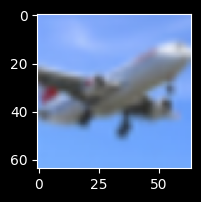

In [3]:
sample_data = next(iter(test_loader))

# Visualize the original image that is sample to test canonicalization
sample_image = invert_normalize(sample_data[0][0]).permute(1, 2, 0).numpy()

plt.figure(figsize=(2, 2))
plt.imshow(sample_image)
plt.show()

In [4]:
def plot_image_tensors(image_tensors, titles=None, figsize=(4, 4)):
    """
    Plots a list of image tensors in a grid.

    Parameters:
    - image_tensors: List[Tensor]. A list of image tensors in (C, H, W) format.
    - titles: List[str]. Optional. A list of titles for each subplot.
    - figsize: tuple. The figure size.
    """
    # Determine the number of images
    num_images = len(image_tensors)

    # Calculate grid size for the subplots
    rows = int(torch.sqrt(torch.tensor(num_images)).item())
    cols = (num_images + rows - 1) // rows  # Ensure enough columns to display all images

    # Create a figure with subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    # Flatten axes array for easy iteration, in case of a single row/column
    axes = axes.flatten()

    # Loop through all the images and their corresponding axes
    for i, (img_tensor, ax) in enumerate(zip(image_tensors, axes)):
        # Convert the tensor for visualization
        img_np = invert_normalize(img_tensor.squeeze()).permute(1, 2, 0).numpy()
        
        # Plot the image
        ax.imshow(img_np)
        ax.axis('off')  # Hide the axis

        # Set title if titles are provided
        if titles and i < len(titles):
            ax.set_title(titles[i])

    # If there are more axes than images, hide the extra axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [5]:
# Transform the image using k random rotations
# number of random rotations
k = 4
# Original tensor image from the DataLoader
sample_image_tensor = sample_data[0][0]  # Assuming the first item is your image tensor

# Define an empty list to store the transformed tensor images
transformed_sample_images = []

# Get the shape of the image tensor
h, w = sample_image_tensor.shape[-2:]

# Pad the image to get rid of the black borders
pad = transforms.Pad(10, padding_mode='edge')

# crop the image to get rid of the black borders
crop = transforms.CenterCrop((h, w))
# Loop over the number of random rotations
# and transform the image tensor using torch rotation
for i in range(2 * k):
    # Generate a random angle for rotation
    angle = (360/k) * i
    
    # Pad the image to get rid of the black borders
    padded_image_tensor = pad(sample_image_tensor)
    
    # Apply the rotation to the tensor
    transformed_image_tensor = F.rotate(padded_image_tensor, angle)
    
    if i >= k:
        transformed_image_tensor = F.hflip(transformed_image_tensor)
    
    # Add the transformed tensor to the list
    transformed_sample_images.append(crop(transformed_image_tensor))



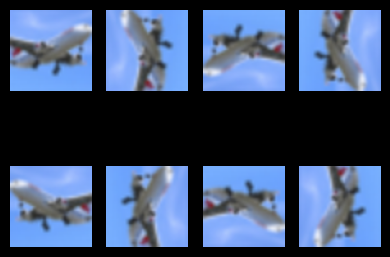

In [6]:
# Visualizing all the transformed images 
plot_image_tensors(transformed_sample_images)

In [7]:
def get_and_plot_canonicalized_images(transformed_sample_images, canonicalizer): 
    # Set the canonicalizer to evaluation mode
    canonicalizer.eval()
    
    # Get canonicalized images for all transformed images
    with torch.no_grad():
        canonicalized_images = []
        for im in transformed_sample_images:
            im = im.unsqueeze(0).to(device)
            canonicalized_image = canonicalizer.canonicalize(im)
            canonicalized_images.append(canonicalized_image.detach().cpu())

    # Visualizing all the canonicalized images
    plot_image_tensors(canonicalized_images)

In [8]:
# Define the hyperparameters for the canonicalization network
class CanonicalizationHyperparams:
    def __init__(self):
        self.input_crop_ratio = 0.9 # The ratio of the input image to crop
        self.beta = 1.0 # Beta parameter for the canonization network
        self.resize_shape = 64 # The shape of the image after resizing

# Create an instance of the hyperparameters
canonicalization_hyperparams = CanonicalizationHyperparams()

# Get the shape of the image
image_shape = sample_image_tensor.squeeze().shape

# Print the image shape
print(f"Image shape: {image_shape}")

# Define a steerable canonicalization network
# Note that you define any steerable network here as long as it outputs 
# a vector that steers with the input image
# This vector is used to get a rotation matrix in a differentiable manner 
canonicalization_network = ESCNNEquivariantNetwork(
    in_shape = image_shape,
    out_channels=16, 
    kernel_size= 9, 
    num_layers = 3,
    group_type='roto-reflection', 
    num_rotations=4, 
).to(device)


# Create a steerable canonicalization object
canonicalizer = GroupEquivariantImageCanonicalization(
    canonicalization_network=canonicalization_network,
    canonicalization_hyperparams=canonicalization_hyperparams,
    in_shape=image_shape,
)


Image shape: torch.Size([3, 64, 64])


/home/mila/s/siba-smarak.panigrahi/.conda/envs/equiadapt/lib/python3.10/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /opt/conda/conda-bld/pytorch_1704987394225/work/aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


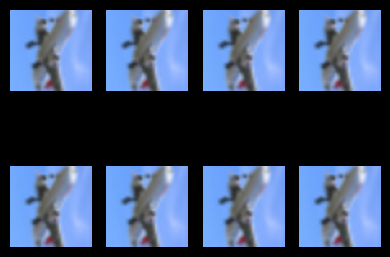

In [9]:
# Visualize the canonicalized images before training the canonicalization network using optimization method
get_and_plot_canonicalized_images(transformed_sample_images, canonicalizer)

In [10]:
# Train the canonicalization network using prior regularization

# Define the optimizer
optimizer = torch.optim.Adam(canonicalization_network.parameters(), lr=0.002)

# Set the canonicalizer to training mode
canonicalizer.train()

# Set a weight for the prior regularization loss
prior_regularization_weight = 100

# Define the training loop
num_epochs = 15
for epoch in range(num_epochs):
    # Initialize tqdm with an initial description
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    identity_metric = 0
    total_loss = 0  # To track the total loss for averaging
    
    for image, _ in train_loader_tqdm:
        # Zero the gradients
        optimizer.zero_grad()
        
        image = image.to(device)
        canonicalized_image = canonicalizer.canonicalize(image)
        
        # Get the prior regularization loss
        loss = prior_regularization_weight * canonicalizer.get_prior_regularization_loss()
        
        # Backpropagate the gradients
        loss.backward()
        
        # Optimize
        optimizer.step()
        
        # Update the running average of identity metric
        identity_metric += canonicalizer.get_identity_metric()

        # Update total loss for averaging
        total_loss += loss.item()

        # Update tqdm description with current loss (average loss per batch)
        train_loader_tqdm.set_description(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/(train_loader_tqdm.n + 1):.4f}")
    
    # Calculate and print the average loss and identity metric over the epoch
    avg_loss = total_loss / len(train_loader)
    identity_metric /= len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}, Identity Metric: {identity_metric:.4f}")    
    
    

Epoch 1/15, Loss: 179.6594: 100%|██████████| 98/98 [00:38<00:00,  2.54it/s]


Epoch 1/15, Average Loss: 179.6594, Identity Metric: 0.2652


Epoch 2/15, Loss: 164.4155: 100%|██████████| 98/98 [00:37<00:00,  2.61it/s]


Epoch 2/15, Average Loss: 164.4155, Identity Metric: 0.3056


Epoch 3/15, Loss: 156.8806: 100%|██████████| 98/98 [00:38<00:00,  2.58it/s]


...

Epoch 13/15, Average Loss: 141.4252, Identity Metric: 0.3557


Epoch 14/15, Loss: 140.5554: 100%|██████████| 98/98 [00:37<00:00,  2.61it/s]


Epoch 14/15, Average Loss: 140.5554, Identity Metric: 0.3596


Epoch 15/15, Loss: 140.2165: 100%|██████████| 98/98 [00:37<00:00,  2.62it/s]

Epoch 15/15, Average Loss: 140.2165, Identity Metric: 0.3589


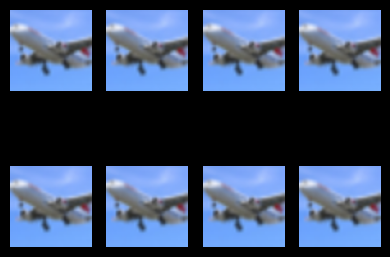

In [11]:
get_and_plot_canonicalized_images(transformed_sample_images, canonicalizer)

In [17]:
# Define the hyperparameters for the canonicalization network
from equiadapt.images.canonicalization_networks.custom_nonequivariant_networks import WideResNet50Network


class CanonicalizationHyperparams:
    def __init__(self):
        self.group_type = "roto-reflection" # Type of group for the canonization network
        self.num_rotations = 4
        self.input_crop_ratio = 0.9 # The ratio of the input image to crop
        self.beta = 1.0 # Beta parameter for the canonization network
        self.resize_shape = 64 # The shape of the image after resizing
        self.artifact_weight = 0 # The weight for the artifact error loss
        self.learn_ref_vec = False # Whether to learn the reference vector
        
# Create an instance of the hyperparameters
opt_canonicalization_hyperparams = CanonicalizationHyperparams()

# Get the shape of the image
image_shape = sample_image_tensor.squeeze().shape

# Print the image shape
print(f"Image shape: {image_shape}")

# Define a steerable canonicalization network
# Note that you define any steerable network here as long as it outputs 
# a vector that steers with the input image
# This vector is used to get a rotation matrix in a differentiable manner 
opt_canonicalization_network = WideResNet50Network(
    in_shape = image_shape,
    out_channels=16, 
    kernel_size= 5, 
    num_layers = 3,
    out_vector_size=128,
).to(device)


# Create a steerable canonicalization object
opt_canonicalizer = OptimizedGroupEquivariantImageCanonicalization(
    canonicalization_network=opt_canonicalization_network,
    canonicalization_hyperparams=opt_canonicalization_hyperparams,
    in_shape=image_shape,
).to(device)

Image shape: torch.Size([3, 64, 64])


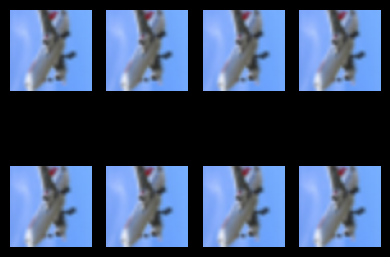

In [18]:
# Visualize the canonicalized images before training the canonicalization network using optimization method
get_and_plot_canonicalized_images(transformed_sample_images, opt_canonicalizer)

In [20]:
# Train the canonicalization network using prior regularization and optimization specific loss

# Define the optimizer
optimizer = torch.optim.Adam(canonicalization_network.parameters(), lr=0.002)

# Set the canonicalizer to training mode
opt_canonicalizer.train()

# Set weights for the losses
prior_regularization_weight = 100
optimization_specific_loss_weight = 0.1

# Define the training loop
num_epochs = 5
for epoch in range(num_epochs):
    # Initialize tqdm with an initial description
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    identity_metric = 0
    total_prior_loss = 0  # To track the total prior regularization loss for averaging
    total_optimization_specific_loss = 0  # To track the total optimization specific loss for averaging
    
    for image, _ in train_loader_tqdm:
        # Zero the gradients
        optimizer.zero_grad()
        
        image = image.to(device)
        canonicalized_image = opt_canonicalizer.canonicalize(image)
        
        # Get the prior regularization loss
        prior_loss = opt_canonicalizer.get_prior_regularization_loss()
        
        # Get the optimization specific loss
        optimization_specific_loss = opt_canonicalizer.get_optimization_specific_loss()
        
        # Combine the losses
        loss = prior_regularization_weight * prior_loss + optimization_specific_loss_weight * optimization_specific_loss
        
        # Backpropagate the gradients
        loss.backward()
        
        # Optimize
        optimizer.step()
        
        # Update the running average of identity metric and loss totals
        identity_metric += canonicalizer.get_identity_metric()
        total_prior_loss += prior_loss.item()
        total_optimization_specific_loss += optimization_specific_loss.item()

        # Update tqdm description with current losses
        train_loader_tqdm.set_description(f"Epoch {epoch+1}/{num_epochs}, Prior Loss: {total_prior_loss/(train_loader_tqdm.n + 1):.4f}, Opt Loss: {total_optimization_specific_loss/(train_loader_tqdm.n + 1):.4f}")
    
    # Calculate and print the average losses and identity metric over the epoch
    avg_prior_loss = total_prior_loss / len(train_loader)
    avg_optimization_specific_loss = total_optimization_specific_loss / len(train_loader)
    identity_metric /= len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Avg Prior Loss: {avg_prior_loss:.4f}, \
          Avg Opt Loss: {avg_optimization_specific_loss:.4f}, Identity Metric: {identity_metric:.4f}")

   

Epoch 1/5:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 1/5,Prior Loss: 2.0808, Opt Loss: 0.3042: 100%|██████████| 98/98 [00:43<00:00,  2.25it/s]


Epoch 1/5, Avg Prior Loss: 2.0808,           Avg Opt Loss: 0.3042, Identity Metric: 0.3770


Epoch 2/5,Prior Loss: 2.0811, Opt Loss: 0.3041: 100%|██████████| 98/98 [00:43<00:00,  2.25it/s]


Epoch 2/5, Avg Prior Loss: 2.0811,           Avg Opt Loss: 0.3041, Identity Metric: 0.3770


...

Epoch 3/5, Avg Prior Loss: 2.0804,           Avg Opt Loss: 0.3041, Identity Metric: 0.3770


Epoch 4/5,Prior Loss: 2.0812, Opt Loss: 0.3044: 100%|██████████| 98/98 [00:43<00:00,  2.25it/s]


Epoch 4/5, Avg Prior Loss: 2.0812,           Avg Opt Loss: 0.3044, Identity Metric: 0.3770


Epoch 5/5,Prior Loss: 2.0809, Opt Loss: 0.3043: 100%|██████████| 98/98 [00:43<00:00,  2.26it/s]

Epoch 5/5, Avg Prior Loss: 2.0809,           Avg Opt Loss: 0.3043, Identity Metric: 0.3770


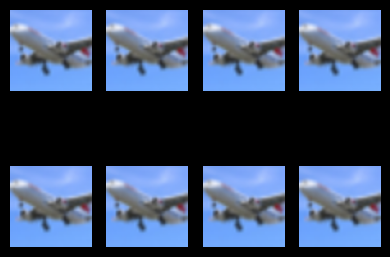

In [21]:
# Visualize the canonicalized images before training the canonicalization network using optimization method
get_and_plot_canonicalized_images(transformed_sample_images, canonicalizer)